<a href="https://colab.research.google.com/github/DivineUI/FairLoan/blob/main/Pipeline.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## The full pipeline


In [65]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OrdinalEncoder, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, ConfusionMatrixDisplay
)

In [66]:
from google.colab import files

uploaded = files.upload()

Saving loan_data.csv to loan_data (6).csv


### Cleaning the data


In [67]:

df = pd.read_csv('loan_data.csv')

In [68]:
def clean_data(df):
  print("Original shape:", df.shape) # check shape
  print(df.isnull().sum())  # check missing values
  print("Duplicate rows:", df.duplicated().sum()) # check for duplicates
  # check numeric columns for outliers
  num_cols = ['person_age','person_income','person_emp_exp','loan_amnt',
            'loan_int_rate','loan_percent_income',
            'cb_person_cred_hist_length','credit_score']
  print(df[num_cols].describe())

  # Find impossible values
  outliers = df[
      (df['person_age'] > 100) |
      (df['person_emp_exp'] > 60) |
      (df['person_emp_exp'] > (df['person_age'] - 18))
  ]
  print("Rows with impossible age/experience:", len(outliers))
  print(outliers[['person_age','person_emp_exp','person_income']])

  # Droping the impossible rows
  df_cleaned = df[
      (df['person_age'] <= 100) &
      (df['person_emp_exp'] <= 60) &
      (df['person_emp_exp'] <= (df['person_age'] - 18))
  ].copy()
  # enconding previous load defaults on file on its own
  df_cleaned['previous_loan_defaults_on_file'] = df_cleaned['previous_loan_defaults_on_file'].map({'No': 0, 'Yes': 1})
  print("New shape after dropping outliers:", df_cleaned.shape)


  return df_cleaned



### Encoding, Splitting, and training

In [69]:
def train_model(df_cleaned):
  # droping target column, gender to avoid bias, and previous_loan_default
  X = df_cleaned.drop(columns=['loan_status', 'person_gender', 'previous_loan_defaults_on_file'])
  y = df_cleaned['loan_status']

  # the different column categories
  numeric_cols = ['person_age', 'person_income', 'person_emp_exp', 'loan_amnt',
                  'loan_int_rate', 'loan_percent_income',
                  'cb_person_cred_hist_length', 'credit_score']

  ordinal_cols = ['person_education']
  education_order = ['High School', 'Associate', 'Bachelor', 'Master', 'Doctorate']

  nominal_cols = ['person_home_ownership', 'loan_intent']

  # encoding
  preprocessor = ColumnTransformer(transformers=[
      ('num', StandardScaler(), numeric_cols),
      ('ord', OrdinalEncoder(categories=[education_order]), ordinal_cols),
      ('nom', OneHotEncoder(handle_unknown='ignore'), nominal_cols)
  ])

  # The pipeline object
  pipeline = Pipeline(steps=[
      ('preprocessor', preprocessor),
      ('classifier', LogisticRegression(max_iter=1000, random_state=42))
  ])

  # Splitting
  X_train, X_test, y_train, y_test = train_test_split(
      X, y, test_size=0.2, random_state=42, stratify=y
  )

  # training
  pipeline.fit(X_train, y_train)

  # predicting and evaluate( calling the other model)
  results = evaluate_model(pipeline, X_test, y_test, title='Confusion Matrix of Pipelined Model')

  return pipeline, results

### Evaluation

In [70]:
def evaluate_model(pipeline, X_test, y_test, title="Confusion Matrix"):
  # predicting
  y_pred = pipeline.predict(X_test)
  # computing the results
  results = {
            'accuracy': accuracy_score(y_test, y_pred),

            'precision': precision_score(y_test, y_pred),
            'recall': recall_score(y_test, y_pred),
            'f1': f1_score(y_test, y_pred),
        }

  print("Accuracy:", accuracy, "| Precision:", precision, "| Recall:", recall, "| F1:", f1)
  # plotting the confusion matrix
  cm = confusion_matrix(y_test, y_pred)

  disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Not Approved (0)', 'Approved (1)'])
  disp.plot(cmap='Blues')
  plt.title('Confusion Matrix of Pipelined Logistic Regression')
  plt.show()

  return results

### The Routing function( for applications)



In [71]:
def predict_with_routing(pipeline, df_cleaned):
    # Routing applicants with a prior default for manual review
    to_review = df_cleaned[df_cleaned['previous_loan_defaults_on_file'] == 1].copy()
    to_review['decision'] = 'Flagged for manual review'

    # Everyone else goes through the model
    to_predict = df_cleaned[df_cleaned['previous_loan_defaults_on_file'] == 0].copy()
    X_new = to_predict.drop(columns=['loan_status', 'person_gender',
                                      'previous_loan_defaults_on_file'], errors='ignore')
    to_predict['decision'] = pipeline.predict(X_new)
    to_predict['decision'] = to_predict['decision'].map({1: 'Approved', 0: 'Not Approved'})

    return pd.concat([to_review, to_predict]).sort_index()

### Main function

In [72]:
def run_pipeline(df):
    df_cleaned = clean_data(df)
    pipeline, results = train_model(df_cleaned)
    final_decisions = predict_with_routing(pipeline, df_cleaned)
    print("Final decisions:")
    print(final_decisions)
    return pipeline, results, final_decisions

Original shape: (45000, 14)
person_age                        0
person_gender                     0
person_education                  0
person_income                     0
person_emp_exp                    0
person_home_ownership             0
loan_amnt                         0
loan_intent                       0
loan_int_rate                     0
loan_percent_income               0
cb_person_cred_hist_length        0
credit_score                      0
previous_loan_defaults_on_file    0
loan_status                       0
dtype: int64
Duplicate rows: 0
         person_age  person_income  person_emp_exp     loan_amnt  \
count  45000.000000   4.500000e+04    45000.000000  45000.000000   
mean      27.764178   8.031905e+04        5.410333   9583.157556   
std        6.045108   8.042250e+04        6.063532   6314.886691   
min       20.000000   8.000000e+03        0.000000    500.000000   
25%       24.000000   4.720400e+04        1.000000   5000.000000   
50%       26.000000   6.70480

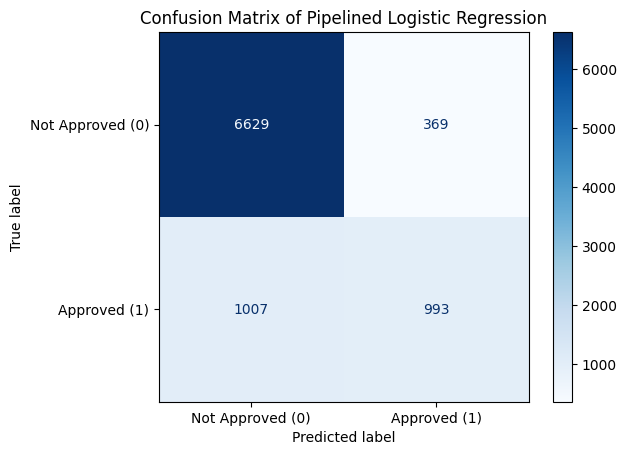

Final decisions:
       person_age person_gender person_education  person_income  \
0            22.0        female           Master        71948.0   
1            21.0        female      High School        12282.0   
2            25.0        female      High School        12438.0   
3            23.0        female         Bachelor        79753.0   
4            24.0          male           Master        66135.0   
...           ...           ...              ...            ...   
44995        27.0          male        Associate        47971.0   
44996        37.0        female        Associate        65800.0   
44997        33.0          male        Associate        56942.0   
44998        29.0          male         Bachelor        33164.0   
44999        24.0          male      High School        51609.0   

       person_emp_exp person_home_ownership  loan_amnt        loan_intent  \
0                   0                  RENT    35000.0           PERSONAL   
1                   0   

,person_age,person_gender,person_education,person_income,person_emp_exp,person_home_ownership,loan_amnt,loan_intent,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,previous_loan_defaults_on_file,loan_status,decision
1,21.0,female,High School,12282.0,0,OWN,1000.0,EDUCATION,11.14,0.08,2.0,504,1,0,Flagged for manual review


In [73]:
pipeline, results, final_decisions = run_pipeline(df)

# separate sanity check, not part of run_pipeline
flagged = final_decisions[final_decisions['decision'] == 'Flagged for manual review']
print("Number flagged:", len(flagged))
flagged.head(1)